##Tree Based Modelling

# 1. Imports and Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import seaborn as sns

# 2. Data Loading and Preprocessing


In [ ]:
# Load your data
df = pd.read_excel("/content/Final_EGX70.xlsx")  # Update path as needed

# Convert to datetime and sort
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d_%H-%M-%S')
df = df.rename(columns={'time': 'date'})
df = df.sort_values('date').reset_index(drop=True)

# Smooth and scale close prices
df['close_smooth'] = df['close'].rolling(window=5).mean()
df = df.dropna().reset_index(drop=True)
scaler = MinMaxScaler()
df['close_scaled'] = scaler.fit_transform(df[['close_smooth']])

# 3. Feature Engineering: Technical Indicators

In [ ]:
# RSI
def compute_rsi(series, window=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    ma_up = up.rolling(window=window, min_periods=0).mean()
    ma_down = down.rolling(window=window, min_periods=0).mean()
    rs = ma_up / (ma_down + 1e-9)
    return 100 - (100 / (1 + rs))

# MACD
def compute_macd(series, fast=12, slow=26, signal=9):
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

# Bollinger Bands
def compute_bollinger(series, window=20, num_std=2):
    ma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper = ma + num_std * std
    lower = ma - num_std * std
    return upper, lower

# Add indicators
df['rsi_14'] = compute_rsi(df['close_smooth'])
df['macd'], df['macd_signal'] = compute_macd(df['close_smooth'])
df['bb_upper'], df['bb_lower'] = compute_bollinger(df['close_smooth'])
df['return_1'] = df['close_smooth'].pct_change()
df['log_return_1'] = np.log(df['close_smooth'] / df['close_smooth'].shift(1))
df['lag_1'] = df['close_smooth'].shift(1)
df = df.dropna().reset_index(drop=True)

# 4. Multi-Class Labeling (Up, Down, Flat)


In [ ]:
# Define thresholds for up, down, flat (e.g., 0.1% move)
up_thresh = 0.001
down_thresh = -0.001

df['label'] = 0  # flat
df.loc[df['return_1'] > up_thresh, 'label'] = 1  # up
df.loc[df['return_1'] < down_thresh, 'label'] = 2  # down

#5. RQA Feature Functions


In [ ]:
def recurrence_rate(R): return np.sum(R) / (R.shape[0] * R.shape[1])
def determinism(R, l_min=2):
    N, det_points, total_points = R.shape[0], 0, np.sum(R)
    for k in range(-N+1, N):
        diag = np.diagonal(R, offset=k)
        ones = np.split(diag, np.where(diag == 0)[0])
        for seg in ones:
            if len(seg) >= l_min: det_points += len(seg)
    return det_points / total_points if total_points > 0 else 0
def laminarity(R, v_min=2):
    N, lam_points, total_points = R.shape[0], 0, np.sum(R)
    for col in range(N):
        col_data = R[:, col]
        ones = np.split(col_data, np.where(col_data == 0)[0])
        for seg in ones:
            if len(seg) >= v_min: lam_points += len(seg)
    return lam_points / total_points if total_points > 0 else 0
def rqa_entropy(R, l_min=2):
    from scipy.stats import entropy
    N, lengths = R.shape[0], []
    for k in range(-N+1, N):
        diag = np.diagonal(R, offset=k)
        ones = np.split(diag, np.where(diag == 0)[0])
        for seg in ones:
            if len(seg) >= l_min: lengths.append(len(seg))
    if not lengths: return 0
    counts = np.bincount(lengths)
    probs = counts / np.sum(counts)
    return entropy(probs, base=2)
def longest_diag_line(R, l_min=2):
    N, max_len = R.shape[0], 0
    for k in range(-N+1, N):
        diag = np.diagonal(R, offset=k)
        ones = np.split(diag, np.where(diag == 0)[0])
        for seg in ones:
            if len(seg) >= l_min: max_len = max(max_len, len(seg))
    return max_len

#6. Feature Extraction with Variable Window Size


In [ ]:
window_size = 30  # Try 20, 30, 40, 60, etc.

features = []
labels = []

for start in range(len(df) - window_size - 1):
    window = df['close_scaled'].values[start:start + window_size]
    diff_matrix = np.abs(window[:, None] - window[None, :])
    epsilon = np.percentile(diff_matrix, 10)
    R = (diff_matrix < epsilon).astype(int)

    # RQA features
    rr = recurrence_rate(R)
    det = determinism(R)
    lam = laminarity(R)
    ent = rqa_entropy(R)
    lmax = longest_diag_line(R)

    idx = start + window_size - 1
    # Technical indicators
    rsi_14 = df.iloc[idx]['rsi_14']
    macd = df.iloc[idx]['macd']
    macd_signal = df.iloc[idx]['macd_signal']
    bb_upper = df.iloc[idx]['bb_upper']
    bb_lower = df.iloc[idx]['bb_lower']
    return_1 = df.iloc[idx]['return_1']
    log_return_1 = df.iloc[idx]['log_return_1']
    lag_1 = df.iloc[idx]['lag_1']

    features.append([rr, det, lam, ent, lmax, rsi_14, macd, macd_signal, bb_upper, bb_lower, return_1, log_return_1, lag_1])
    labels.append(int(df.iloc[start + window_size]['label']))

features = np.array(features)
labels = np.array(labels)

#7. Train/Validation/Test Split (Chronological)


In [ ]:
n = len(features)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

X_train, y_train = features[:train_size], labels[:train_size]
X_val, y_val = features[train_size:train_size+val_size], labels[train_size:train_size+val_size]
X_test, y_test = features[train_size+val_size:], labels[train_size+val_size:]

#8. Model Tuning with Time Series Cross-Validation


In [ ]:
# XGBoost with GridSearchCV and TimeSeriesSplit
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0]
}
tscv = TimeSeriesSplit(n_splits=5)
xgb_clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid_search = GridSearchCV(xgb_clf, param_grid, cv=tscv, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV score: 0.7694323144104803


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:19:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


#9. Evaluate on Validation Set


In [ ]:
best_model = grid_search.best_estimator_
# Use validation set to check performance during tuning
y_pred_val = best_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val, target_names=['Flat', 'Up', 'Down']))

Validation Accuracy: 0.8203389830508474
              precision    recall  f1-score   support

        Flat       0.00      0.00      0.00        24
          Up       0.87      0.93      0.90       197
        Down       0.70      0.80      0.75        74

    accuracy                           0.82       295
   macro avg       0.52      0.58      0.55       295
weighted avg       0.76      0.82      0.79       295



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#10. Feature Importance and Removal


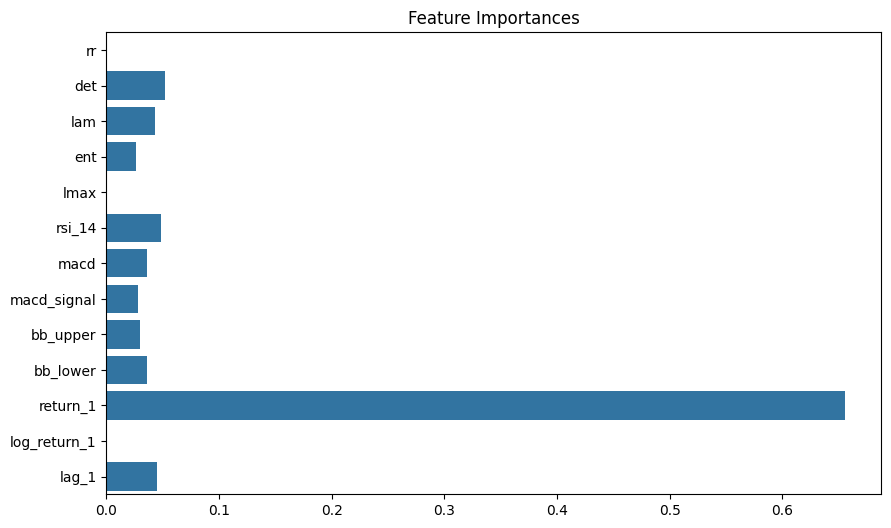

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:19:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test Accuracy (important features): 0.7837837837837838
              precision    recall  f1-score   support

        Flat       0.00      0.00      0.00        28
          Up       0.81      0.90      0.85       172
        Down       0.74      0.81      0.77        96

    accuracy                           0.78       296
   macro avg       0.52      0.57      0.54       296
weighted avg       0.71      0.78      0.74       296



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
importances = best_model.feature_importances_
feature_names = ['rr', 'det', 'lam', 'ent', 'lmax', 'rsi_14', 'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'return_1', 'log_return_1', 'lag_1']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importances")
plt.show()

# Remove features with very low importance (e.g., < 0.01)
important_indices = np.where(importances > 0.01)[0]
X_train_imp = X_train[:, important_indices]
X_val_imp = X_val[:, important_indices]
X_test_imp = X_test[:, important_indices]

# Retrain with important features only
xgb_clf_imp = xgb.XGBClassifier(objective='multi:softprob', num_class=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42, **grid_search.best_params_)
xgb_clf_imp.fit(X_train_imp, y_train)
y_pred_imp = xgb_clf_imp.predict(X_test_imp)
print("Test Accuracy (important features):", accuracy_score(y_test, y_pred_imp))
print(classification_report(y_test, y_pred_imp, target_names=['Flat', 'Up', 'Down']))

#Plots Accuracy and Loss

In [ ]:
from sklearn.metrics import accuracy_score, log_loss

# Predict on train, validation, and test sets
y_pred_train_imp = xgb_clf_imp.predict(X_train_imp)
y_pred_val_imp = xgb_clf_imp.predict(X_val_imp)
y_pred_test_imp = xgb_clf_imp.predict(X_test_imp)

# For log_loss, need predicted probabilities
y_proba_train_imp = xgb_clf_imp.predict_proba(X_train_imp)
y_proba_val_imp = xgb_clf_imp.predict_proba(X_val_imp)
y_proba_test_imp = xgb_clf_imp.predict_proba(X_test_imp)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train_imp)
val_acc = accuracy_score(y_val, y_pred_val_imp)
test_acc = accuracy_score(y_test, y_pred_test_imp)

# Log Loss
train_loss = log_loss(y_train, y_proba_train_imp)
val_loss = log_loss(y_val, y_proba_val_imp)
test_loss = log_loss(y_test, y_proba_test_imp)

print(f"Train Accuracy: {train_acc:.4f}, Train Log Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}, Validation Log Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, Test Log Loss: {test_loss:.4f}")

Train Accuracy: 0.7929, Train Log Loss: 0.6731
Validation Accuracy: 0.8203, Validation Log Loss: 0.7783
Test Accuracy: 0.7838, Test Log Loss: 0.8412


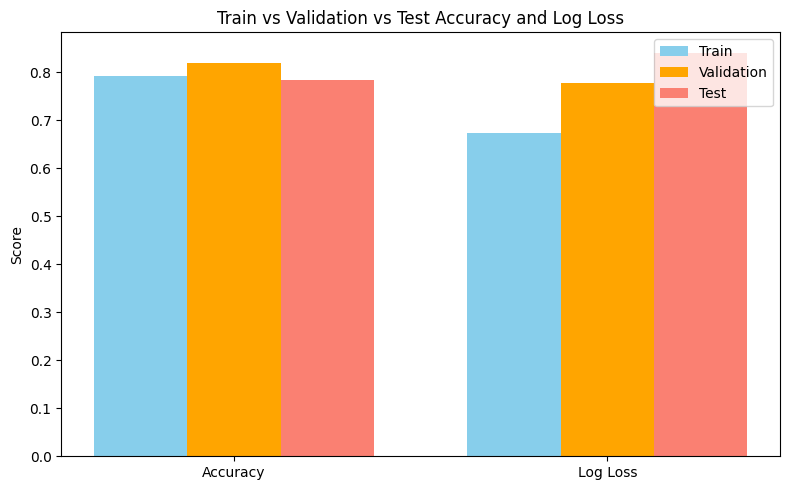

In [ ]:

# Data for plotting
metrics = ['Accuracy', 'Log Loss']
train_scores = [train_acc, train_loss]
val_scores = [val_acc, val_loss]
test_scores = [test_acc, test_loss]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, train_scores, width, label='Train', color='skyblue')
plt.bar(x, val_scores, width, label='Validation', color='orange')
plt.bar(x + width, test_scores, width, label='Test', color='salmon')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Train vs Validation vs Test Accuracy and Log Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Number of features before selection:", X_train.shape[1])
print("Number of features after selection:", X_train_imp.shape[1])

Number of features before selection: 13
Number of features after selection: 10


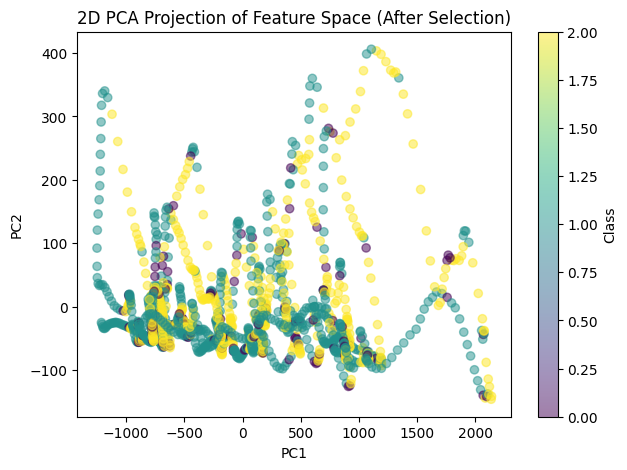

In [ ]:
from sklearn.decomposition import PCA

# Use only the features kept after selection
X_vis = X_train_imp

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='viridis', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection of Feature Space (After Selection)')
plt.colorbar(label='Class')
plt.show()

#Recuurence Plot

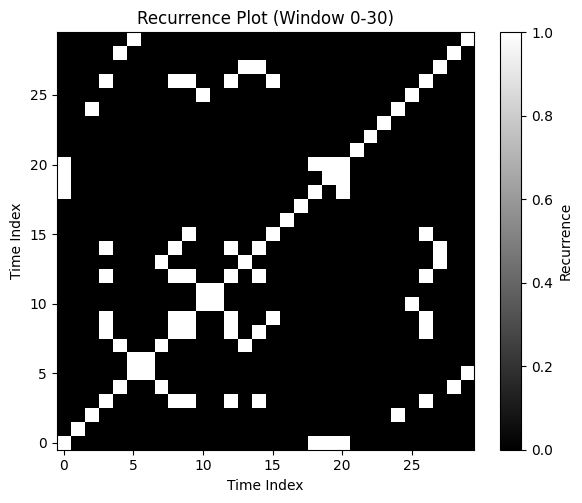

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a window size (same as your model)
window_size = 30

# Pick a starting index (e.g., 0 for the first window)
start_idx = 0
window = df['close_scaled'].values[start_idx:start_idx + window_size]

# Compute the recurrence matrix
diff_matrix = np.abs(window[:, None] - window[None, :])
epsilon = np.percentile(diff_matrix, 10)  # 10th percentile threshold
recurrence_matrix = (diff_matrix < epsilon).astype(int)

# Visualize the recurrence plot
plt.figure(figsize=(6, 5))
plt.imshow(recurrence_matrix, cmap='gray', origin='lower')
plt.title(f"Recurrence Plot (Window {start_idx}-{start_idx+window_size})")
plt.xlabel("Time Index")
plt.ylabel("Time Index")
plt.colorbar(label="Recurrence")
plt.tight_layout()
plt.show()

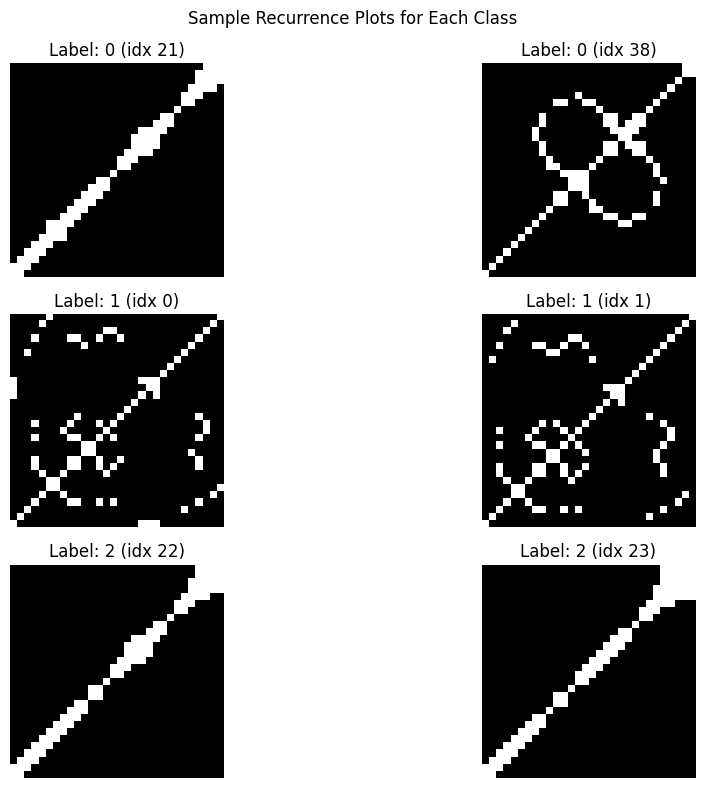

In [ ]:
# Let's show a few samples for each class (up, down, flat)
labels_to_show = [0, 1, 2]  # Flat, Up, Down
n_samples_per_class = 2

plt.figure(figsize=(12, 8))
plot_idx = 1
for label in labels_to_show:
    # Find indices of this class
    indices = np.where(labels == label)[0][:n_samples_per_class]
    for idx in indices:
        window = df['close_scaled'].values[idx:idx + window_size]
        diff_matrix = np.abs(window[:, None] - window[None, :])
        epsilon = np.percentile(diff_matrix, 10)
        recurrence_matrix = (diff_matrix < epsilon).astype(int)
        plt.subplot(len(labels_to_show), n_samples_per_class, plot_idx)
        plt.imshow(recurrence_matrix, cmap='gray', origin='lower')
        plt.title(f"Label: {label} (idx {idx})")
        plt.axis('off')
        plot_idx += 1
plt.suptitle("Sample Recurrence Plots for Each Class")
plt.tight_layout()
plt.show()